In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
currency_formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
percent_formatter = ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%')

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [9]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.shape

(9994, 21)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [15]:
# data preparation

df['Profit Margin'] = df['Profit'] / df['Sales']
df['Loss Flag'] = df['Profit'].apply(lambda x: 1 if x < 0 else 0)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country         9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9994 non-null   int64         
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

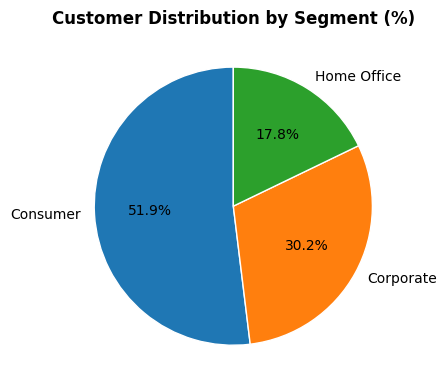

In [18]:
# univariate analysis
#segemnt
segament_percentage = df['Segment'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 1, figsize=(6, 4), sharey=False)

segament_percentage.plot(
    kind='pie',
    ax=axes,
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    autopct='%1.1f%%'
)
axes.set_title('Customer Distribution by Segment (%)', fontsize=12, fontweight='bold')
axes.set_ylabel('')
axes.set_xlabel('')

plt.tight_layout()
plt.show()

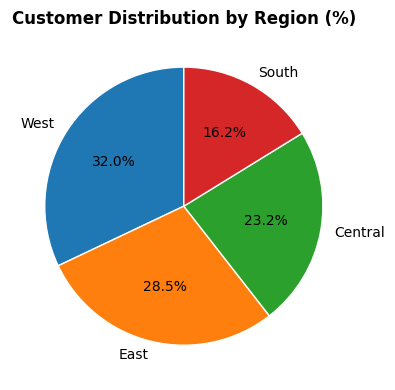

In [19]:
# REGION
region_percentage = df['Region'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 1, figsize=(6, 4), sharey=False)

region_percentage.plot(
    kind='pie',
    ax=axes,
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    autopct='%1.1f%%'
)
axes.set_title('Customer Distribution by Region (%)', fontsize=12, fontweight='bold')
axes.set_ylabel('')
axes.set_xlabel('')

plt.tight_layout()
plt.show()

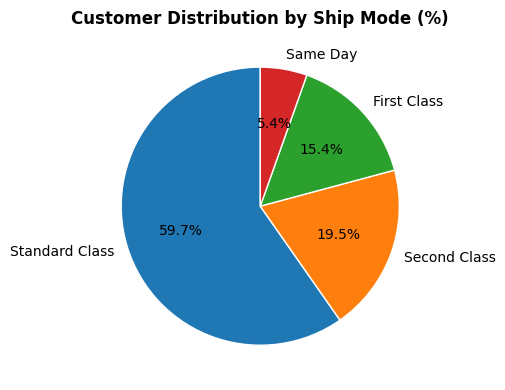

In [20]:
# SHIP MODE
ship_mode_percentage = df['Ship Mode'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 1, figsize=(6, 4), sharey=False)

ship_mode_percentage.plot(
    kind='pie',
    ax=axes,
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    autopct='%1.1f%%'
)
axes.set_title('Customer Distribution by Ship Mode (%)', fontsize=12, fontweight='bold')
axes.set_ylabel('')
axes.set_xlabel('')

plt.tight_layout()
plt.show()

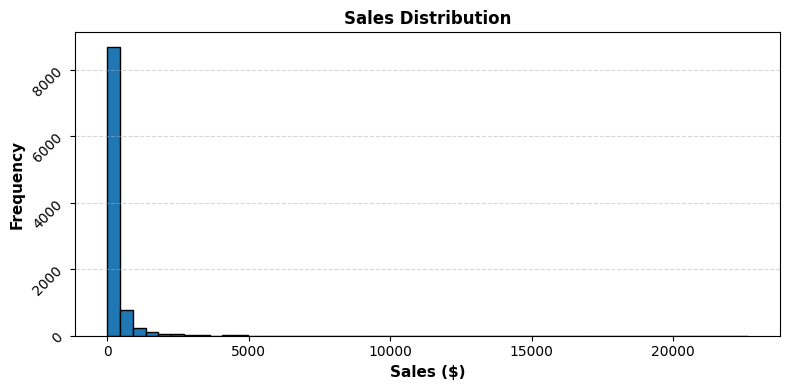

In [21]:
# SALES
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharey=False)

ax.hist(df['Sales'], bins=50, edgecolor='black')
ax.set_title("Sales Distribution", fontsize=12, fontweight='bold')
ax.set_xlabel('Sales ($)', fontsize=11, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

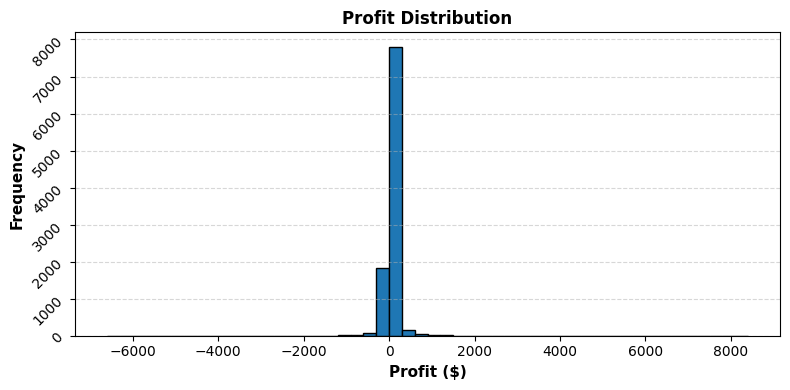

In [22]:
# PROFIT
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharey=False)

ax.hist(df['Profit'], bins=50, edgecolor='black')
ax.set_title("Profit Distribution", fontsize=12, fontweight='bold')
ax.set_xlabel("Profit ($)", fontsize=11, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

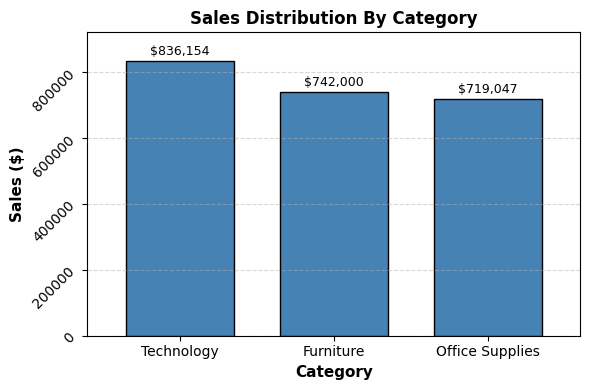

In [24]:
# PRODUCT ANALYSIS
# category performance analysis
# total sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plot_xlabel = 'Category'
plot_ylabel = 'Sales ($)'
plot_title = 'Sales Distribution By Category'


fig, ax = plt.subplots(figsize=(6,4))

category_sales.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

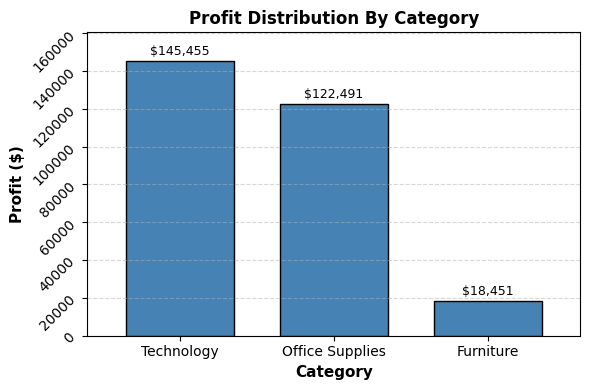

In [25]:
# total profit
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plot_xlabel = 'Category'
plot_ylabel = 'Profit ($)'
plot_title = 'Profit Distribution By Category'

fig, ax = plt.subplots(figsize=(6,4))

category_profit.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

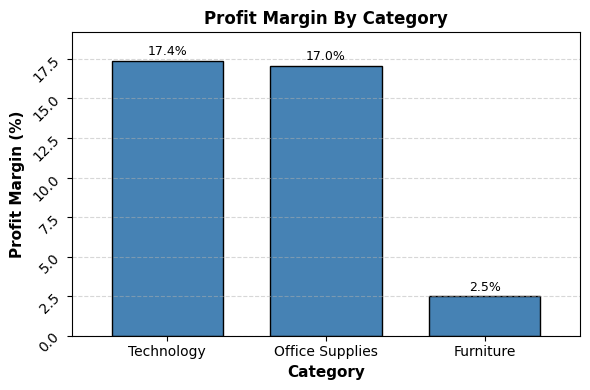

In [26]:
# profit margin
category_profit_margin = (
    df.groupby('Category')['Profit'].sum() /  df.groupby('Category')['Sales'].sum()
).sort_values(ascending=False)
category_profit_margin_pct = category_profit_margin * 100

plot_xlabel = 'Category'
plot_ylabel = 'Profit Margin (%)'
plot_title = 'Profit Margin By Category'

fig, ax = plt.subplots(figsize=(6,4))

category_profit_margin_pct.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

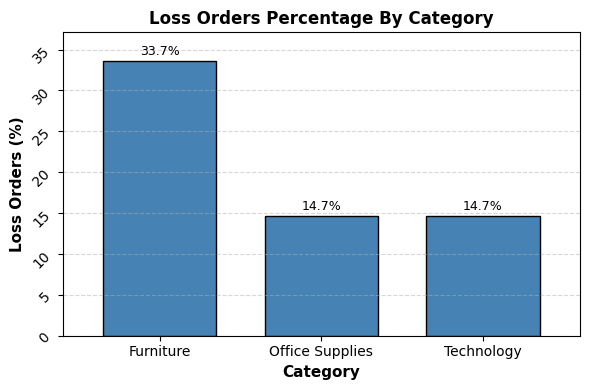

In [27]:
# % of loss orders
loss_order_pct = (
    df[df['Loss Flag'] == 1]
    .groupby('Category')
    .size() / df.groupby('Category').size()
) * 100

plot_xlabel = 'Category'
plot_ylabel = 'Loss Orders (%)'
plot_title = 'Loss Orders Percentage By Category'

fig, ax = plt.subplots(figsize=(6,4))

loss_order_pct.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()


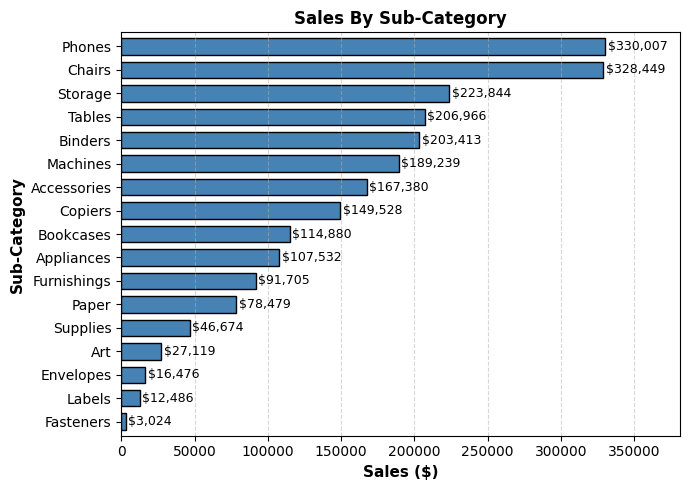

In [29]:
# Sub category performance analysis
# total sales(ranked)
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)

plot_xlabel = 'Sales ($)'
plot_ylabel = 'Sub-Category'
plot_title = 'Sales By Sub-Category'


fig, ax = plt.subplots(figsize=(7,5))

subcategory_sales.plot(kind='barh',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)

ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.show()

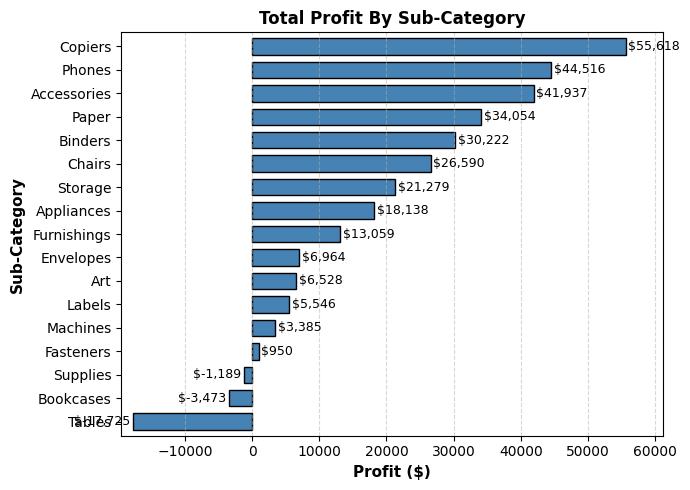

In [31]:
# total profit(ranked)
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=True)
)

plot_xlabel = 'Profit ($)'
plot_ylabel = 'Sub-Category'
plot_title = 'Total Profit By Sub-Category'

fig, ax = plt.subplots(figsize=(7,5))

subcategory_profit.plot(
    kind='barh',
    ax=ax,
    color='steelblue',
    edgecolor='black',
    width=0.7
)

ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', labelsize=10)

# Important: Allow negative profits to show
ax.set_xlim(
    subcategory_profit.min() * 1.1,
    subcategory_profit.max() * 1.1
)

plt.tight_layout()
plt.show()

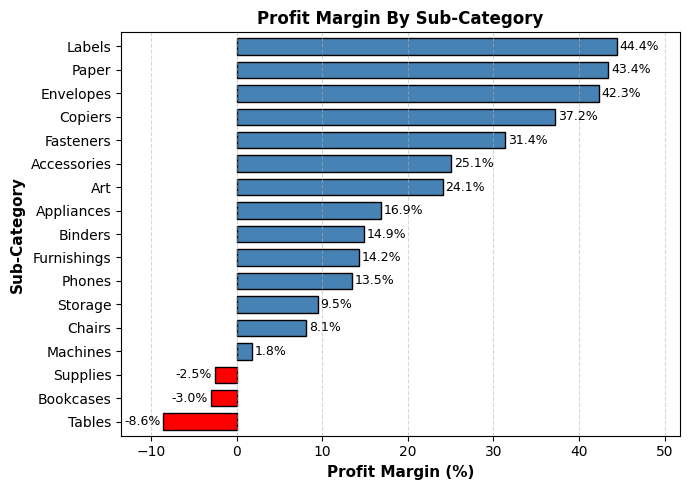

In [ ]:
# profit margin
subcategory_profit_margin = (
    df.groupby('Sub-Category')['Profit'].sum() / df.groupby('Sub-Category')['Sales'].sum()
).sort_values()
subcategory_profit_margin_pct = subcategory_profit_margin * 100

plot_xlabel = 'Profit Margin (%)'
plot_ylabel = 'Sub-Category'
plot_title = 'Profit Margin By Sub-Category'


fig, ax = plt.subplots(figsize=(7,5))

conditional_colors = ['red' if val < 0 else 'steelblue' for val in subcategory_profit_margin]

subcategory_profit_margin_pct.plot(kind='barh',ax=ax, color=conditional_colors, edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.set_xlim(ax.get_xlim()[0] * 1.2, ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.show()

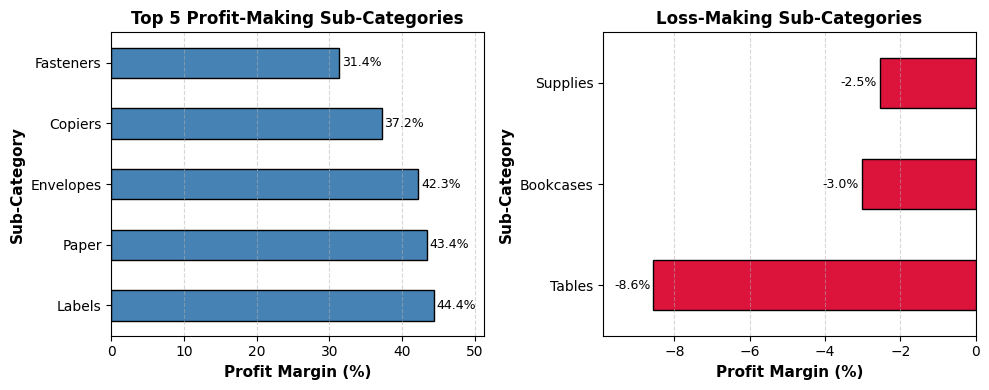

In [33]:
# top profit vs top loss Sub-Categories
positive = subcategory_profit_margin_pct[subcategory_profit_margin_pct > 0].sort_values(ascending=False)
negative = subcategory_profit_margin_pct[subcategory_profit_margin_pct < 0].sort_values()

top_profit = positive.head(5)
top_loss   = negative.head(5)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

top_profit.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)
axes[0].set_title('Top 5 Profit-Making Sub-Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit Margin (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sub-Category', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.1)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

top_loss.plot(kind='barh', ax=axes[1], color='crimson', edgecolor='black')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)
axes[1].set_title('Loss-Making Sub-Categories', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Profit Margin (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Sub-Category', fontsize=11, fontweight='bold')
axes[1].set_xlim(axes[1].get_xlim()[0] * 1.1, 0)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

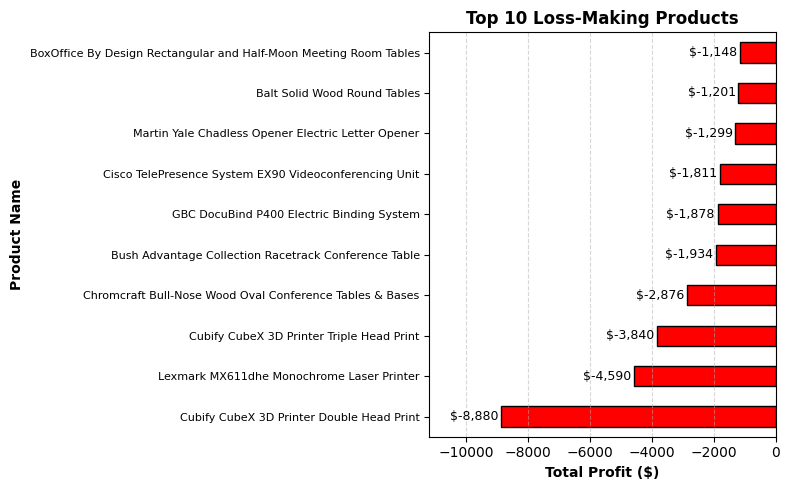

In [34]:
# product loss snapshot
worst_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

fig, ax = plt.subplots(1, 1, figsize=(8,5))

worst_products.plot(kind='barh', ax=ax, color='red', edgecolor='black')
for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)
ax.set_title("Top 10 Loss-Making Products", fontsize=12, fontweight='bold')
ax.set_xlabel("Total Profit ($)", fontsize=10, fontweight='bold')
ax.set_ylabel("Product Name", fontsize=10, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(ax.get_xlim()[0] * 1.2, 0)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

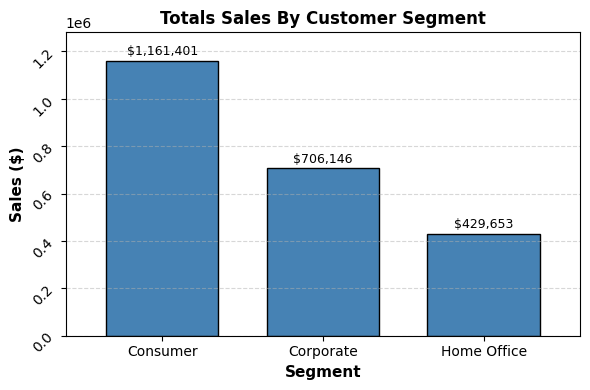

In [35]:
# CUSTOMER ANALYSIS
# customer segment performance
# total sales
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plot_xlabel = 'Segment'
plot_ylabel = 'Sales ($)'
plot_title = 'Totals Sales By Customer Segment'

fig, ax = plt.subplots(figsize=(6,4))

segment_sales.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

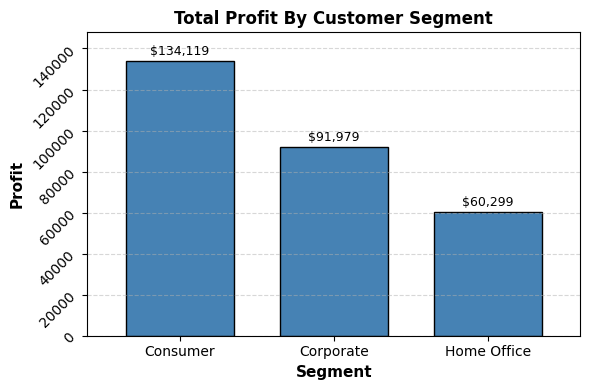

In [36]:
# Total profit
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

plot_xlabel = 'Segment'
plot_ylabel = 'Profit'
plot_title = 'Total Profit By Customer Segment'

fig, ax = plt.subplots(figsize=(6,4))

segment_profit.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

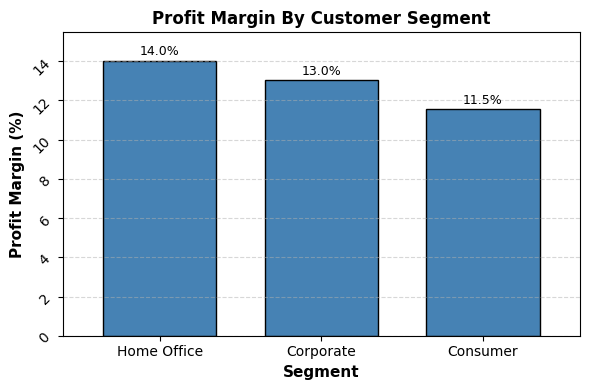

In [37]:
# profit margin
segment_profit_margin = (
    df.groupby('Segment')['Profit'].sum() / df.groupby('Segment')['Sales'].sum()
).sort_values(ascending=False)
segment_profit_margin_pct = segment_profit_margin * 100

plot_xlabel = 'Segment'
plot_ylabel = 'Profit Margin (%)'
plot_title = 'Profit Margin By Customer Segment'

fig, ax = plt.subplots(figsize=(6,4))

segment_profit_margin_pct.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

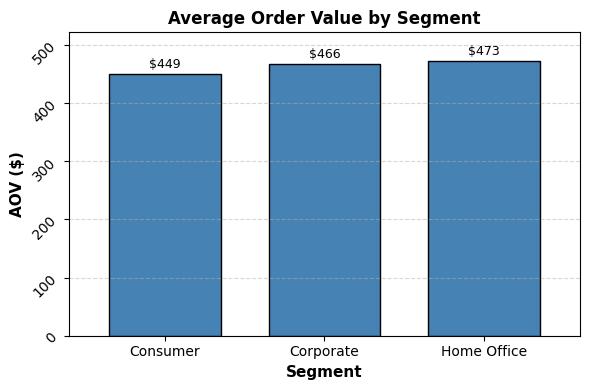

In [38]:
#AOV_per_segment = Total Sales per segment / Total Orders per segment
aov_segment = df.groupby('Segment')['Sales'].sum() / df.groupby('Segment')['Order ID'].nunique()

plot_xlabel = 'Segment'
plot_ylabel = 'AOV ($)'
plot_title = 'Average Order Value by Segment'

fig, ax = plt.subplots(figsize=(6,4))

aov_segment.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

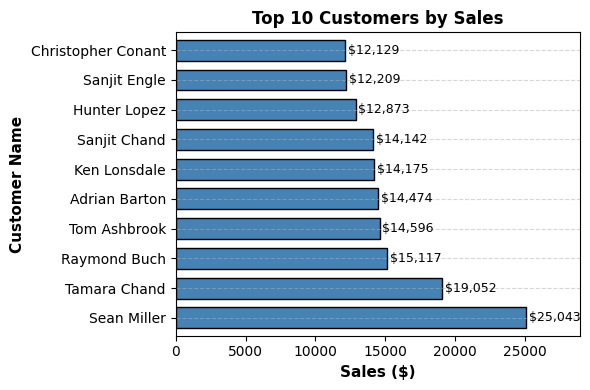

In [39]:
# top customer contribution analysis
# top 10 by sales
top10_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plot_xlabel = 'Sales ($)'
plot_ylabel = 'Customer Name'
plot_title = 'Top 10 Customers by Sales'

fig, ax = plt.subplots(figsize=(6,4))

top10_sales.plot(kind='barh',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.show()

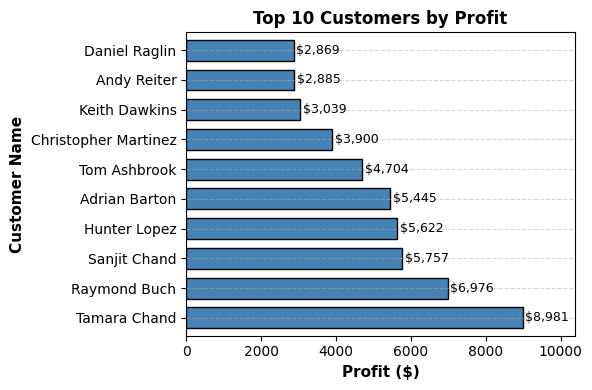

In [40]:
# top 10 by profit
top10_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

plot_xlabel = 'Profit ($)'
plot_ylabel = 'Customer Name'
plot_title = 'Top 10 Customers by Profit'

fig, ax = plt.subplots(figsize=(6,4))

top10_profit.plot(kind='barh',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.show()

In [41]:
# customrer concentration metric
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

top10_sales = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top10_sales_pct = (top10_sales.sum() / total_sales) * 100

top10_profit = (
    df.groupby('Customer Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top10_profit_pct = (top10_profit.sum() / total_profit) * 100

"""top10_sales_pct, top10_profit_pct     * **Top 10 customers contribute ~6.7% of total sales.**
* **Top 10 customers contribute ~17.5% of total profit.**"""


(np.float64(6.695590779985744), np.float64(17.520457092099715))

In [42]:
  # customer purchase behaviour
  # (customer summary tble)
  # Total company values
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
customer_summary = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
})
customer_summary.rename(columns={'Order ID': 'Total Orders'}, inplace=True)
customer_summary['Profit Margin %'] = (
    customer_summary['Profit'] / customer_summary['Sales']
) * 100

customer_summary['AOV'] = (
    customer_summary['Sales'] / customer_summary['Total Orders']
)

customer_summary['Sales Contribution %'] = (
    customer_summary['Sales'] / total_sales
) * 100

customer_summary['Profit Contribution %'] = (
    customer_summary['Profit'] / total_profit
) * 100

In [43]:
# Classify Customer Behaviour
# Get medians
sales_median = customer_summary['Sales'].median()
margin_median = customer_summary['Profit Margin %'].median()

def classify_customer(row):
    if row['Sales'] >= sales_median and row['Profit Margin %'] >= margin_median:
        return 'Strategic (High Sales, High Margin)'
    elif row['Sales'] >= sales_median and row['Profit Margin %'] < margin_median:
        return 'Revenue Risk (High Sales, Low Margin)'
    elif row['Sales'] < sales_median and row['Profit Margin %'] >= margin_median:
        return 'Growth Opportunity (Low Sales, High Margin)'
    else:
        return 'Low Priority (Low Sales, Low Margin)'

customer_summary['Customer Segment Type'] = customer_summary.apply(classify_customer, axis=1)

In [44]:
# viewing top customers with behaviour
customer_summary.sort_values('Sales', ascending=False).head(10)

,Sales,Profit,Total Orders,Profit Margin %,AOV,Sales Contribution %,Profit Contribution %,Customer Segment Type
Customer Name,,,,,,,,
Sean Miller,25043.050,-1980.7393,5,-7.909337,5008.610000,1.090155,-0.691606,"Revenue Risk (High Sales, Low Margin)"
Tamara Chand,19052.218,8981.3239,5,47.140569,3810.443600,0.829367,3.135970,"Strategic (High Sales, High Margin)"
Raymond Buch,15117.339,6976.0959,6,46.146322,2519.556500,0.658076,2.435813,"Strategic (High Sales, High Margin)"
Tom Ashbrook,14595.620,4703.7883,4,32.227396,3648.905000,0.635365,1.642401,"Strategic (High Sales, High Margin)"
Adrian Barton,14473.571,5444.8055,10,37.618950,1447.357100,0.630052,1.901139,"Strategic (High Sales, High Margin)"
Ken Lonsdale,14175.229,806.8550,12,5.692007,1181.269083,0.617065,0.281726,"Revenue Risk (High Sales, Low Margin)"
Sanjit Chand,14142.334,5757.4119,9,40.710479,1571.370444,0.615633,2.010290,"Strategic (High Sales, High Margin)"
Hunter Lopez,12873.298,5622.4292,6,43.675127,2145.549667,0.560391,1.963159,"Strategic (High Sales, High Margin)"
Sanjit Engle,12209.438,2650.6769,11,21.710065,1109.948909,0.531492,0.925525,"Strategic (High Sales, High Margin)"


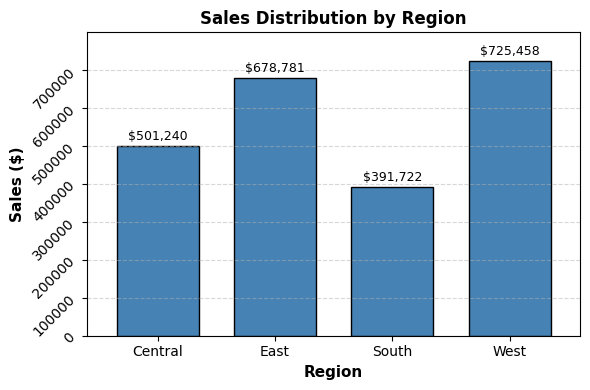

In [45]:
# geographical analysis
# region_level performance
# Totyal sales by region
region_sales = df.groupby('Region')['Sales'].sum()

plot_xlabel = 'Region'
plot_ylabel = 'Sales ($)'
plot_title = 'Sales Distribution by Region'

fig, ax = plt.subplots(figsize=(6,4))

region_sales.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

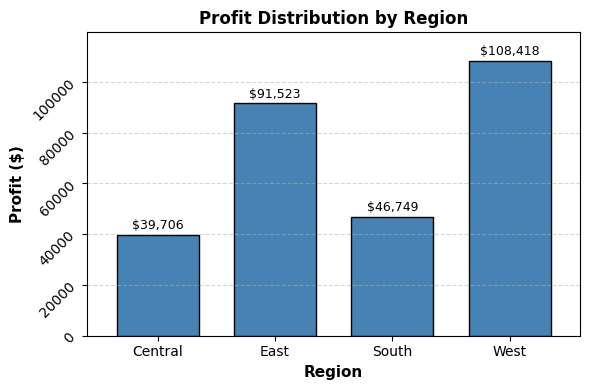

In [46]:
# total profit by region
region_profit = df.groupby('Region')['Profit'].sum()

plot_xlabel = 'Region'
plot_ylabel = 'Profit ($)'
plot_title = 'Profit Distribution by Region'

fig, ax = plt.subplots(figsize=(6,4))

region_profit.plot(kind='bar',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

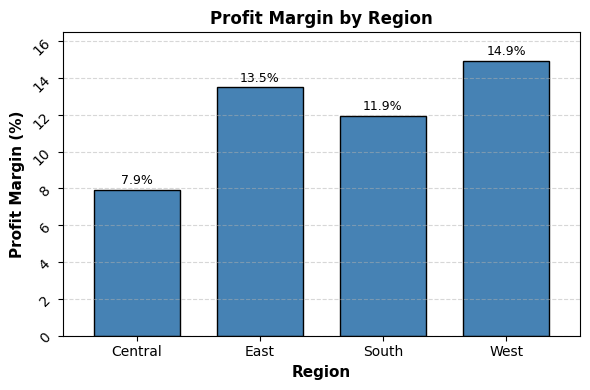

In [47]:
# profit margin by region
region_profit_margin = (
    df.groupby('Region')['Profit'].sum() / df.groupby('Region')['Sales'].sum()
)
region_profit_margin_pct = region_profit_margin * 100

plot_xlabel = 'Region'
plot_ylabel = 'Profit Margin (%)'
plot_title = 'Profit Margin by Region'

fig, ax = plt.subplots(figsize=(6,4))

conditional_colors = ['red' if val < 0 else 'steelblue' for val in region_profit_margin]

region_profit_margin_pct.plot(kind='bar',ax=ax,color=conditional_colors, edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(ax.get_ylim()[0] * 1.05, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

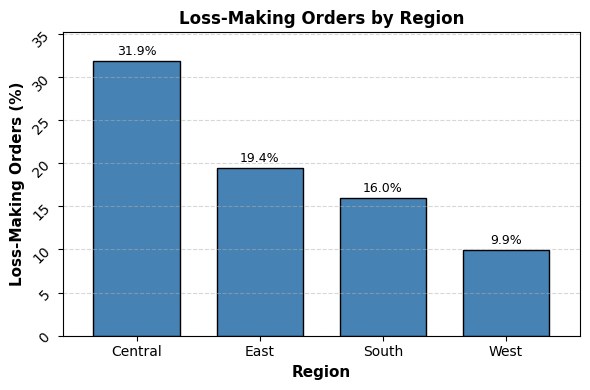

In [48]:
 # per. of loss making orders by region
 region_loss_rate = (df[df['Profit'] < 0].groupby('Region').size() / df.groupby('Region').size()) * 100

plot_xlabel = 'Region'
plot_ylabel = 'Loss-Making Orders (%)'
plot_title = 'Loss-Making Orders by Region'

fig, ax = plt.subplots(figsize=(6,4))

region_loss_rate.plot(kind='bar',ax=ax, color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(ax.get_ylim()[0] * 1.05, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

In [49]:
import plotly.express as px

state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','District of Columbia':'DC',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID','Illinois':'IL',
    'Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
    'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR',
    'Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
    'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

state_profit = df.groupby('State', as_index=False)['Profit'].sum()

state_profit['State'] = state_profit['State'].str.strip()
state_profit = state_profit[state_profit['State'].isin(state_abbrev.keys())].copy()

state_profit['state_code'] = state_profit['State'].map(state_abbrev)

fig = px.choropleth(
    state_profit,
    locations='state_code',
    locationmode='USA-states',
    color='Profit',
    scope='usa',
    color_continuous_scale='RdYlGn',
    hover_data=['State', 'Profit'],
    labels={'Profit': 'Total Profit'},
    title='Total Profit by State'
)

fig.update_layout(margin=dict(l=20,r=20,t=50,b=20))
fig.show()


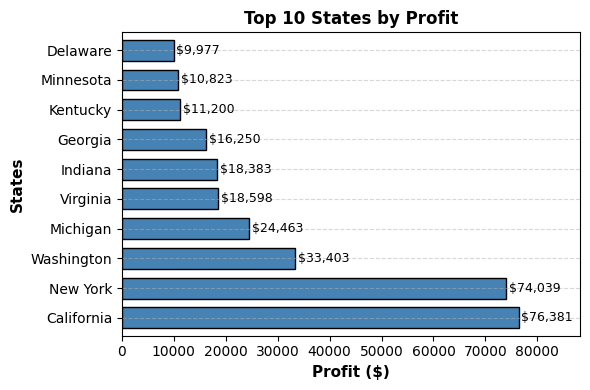

In [50]:
  # top 10 profitable states
  top_10_state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

plot_xlabel = 'Profit ($)'
plot_ylabel = 'States'
plot_title = 'Top 10 States by Profit'

fig, ax = plt.subplots(figsize=(6,4))

top_10_state_profit.plot(kind='barh',ax=ax,color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.show()

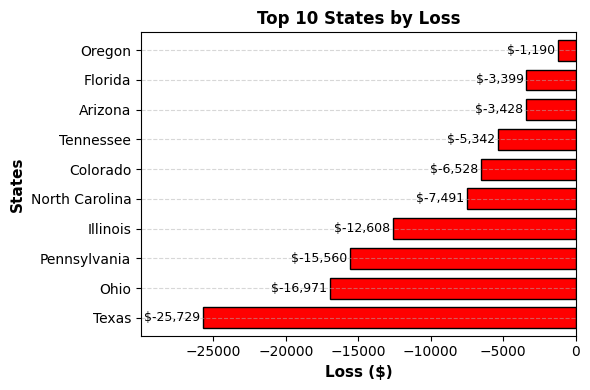

In [51]:
# top 10 loss making states
top_10_state_loss = df.groupby('State')['Profit'].sum().sort_values().head(10)

plot_xlabel = 'Loss ($)'
plot_ylabel = 'States'
plot_title = 'Top 10 States by Loss'

fig, ax = plt.subplots(figsize=(6,4))

top_10_state_loss.plot(kind='barh',ax=ax,color='Red', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.set_xlim(ax.get_xlim()[0] * 1.11, ax.get_xlim()[1])

plt.tight_layout()
plt.show()

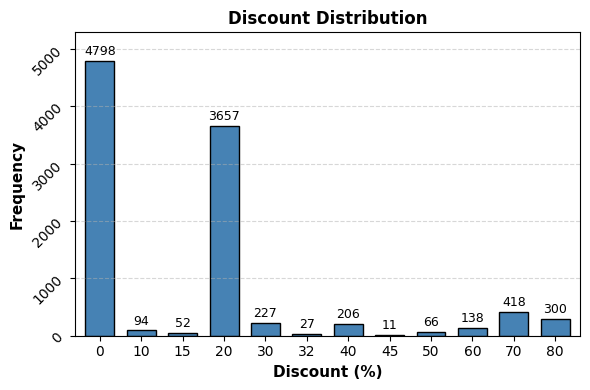

In [52]:
 # discount impact
 discount_counts = df['Discount'].value_counts().sort_index()

plot_xlabel = 'Discount (%)'
plot_ylabel = 'Frequency'
plot_title = 'Discount Distribution'

discount_labels = [int(d*100) for d in discount_counts.index]
discount_counts.index = discount_labels

fig, ax = plt.subplots(figsize=(6,4))
discount_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt='%d', fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(ax.get_ylim()[0] * 1.05, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()


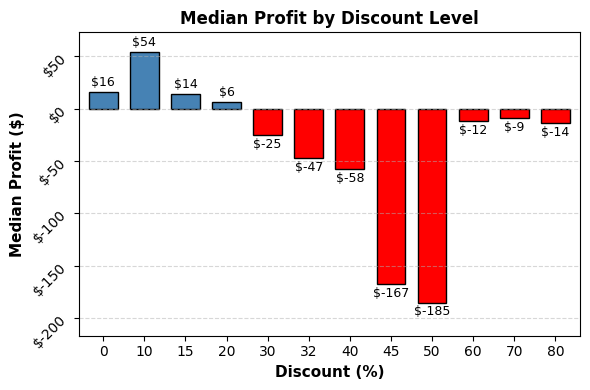

In [53]:
# discount vs profit relationship
median_profit_by_discount = df.groupby('Discount')['Profit'].median().sort_index()

plot_xlabel = 'Discount (%)'
plot_ylabel = 'Median Profit ($)'
plot_title = 'Median Profit by Discount Level'

fig, ax = plt.subplots(figsize=(6,4))

conditional_colors = ['red' if val < 0 else 'steelblue' for val in median_profit_by_discount]

median_profit_by_discount.index = discount_labels

median_profit_by_discount.plot(kind='bar',ax=ax, color=conditional_colors, edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=currency_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(ax.get_ylim()[0] * 1.1, ax.get_ylim()[1] * 1.1)

plt.gca().yaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

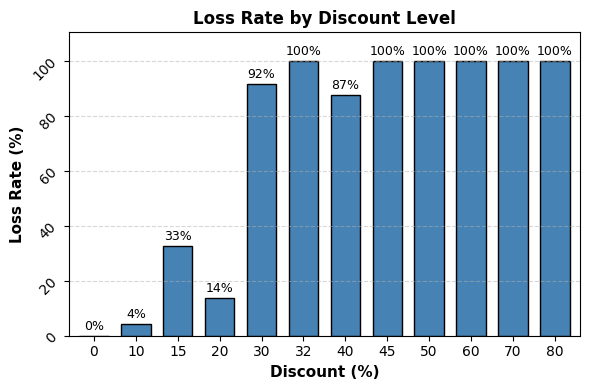

In [54]:
# loss rate by discount level
loss_rate_by_discount = (
    df.groupby('Discount')['Loss Flag'].mean() * 100
).sort_index()

plot_xlabel = 'Discount (%)'
plot_ylabel = 'Loss Rate (%)'
plot_title = 'Loss Rate by Discount Level'

fig, ax = plt.subplots(figsize=(6,4))

loss_rate_by_discount.index = discount_labels

loss_rate_by_discount.plot(kind='bar',ax=ax, color='steelblue', edgecolor='black', width=0.7)
ax.set_title(plot_title, fontsize=12, fontweight='bold')
ax.set_xlabel(plot_xlabel, fontsize=11, fontweight='bold')
ax.set_ylabel(plot_ylabel, fontsize=11, fontweight='bold')

for c in ax.containers:
    ax.bar_label(c, fmt=percent_formatter, fontsize=9, padding=2)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=45, labelsize=10)
ax.set_ylim(ax.get_ylim()[0] * 1.05, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()

#  Conclusion

* Sales are mainly driven by **Consumer customers, Technology products**, and the **West and East regions**.
* **High sales do not guarantee high profit**; Furniture and sub-categories like Tables and Bookcases consistently generate losses.
* **Discounting above 30% leads to near-certain losses**, making discount control the most critical profitability lever.
* Profit is **more concentrated among top customers than sales**, indicating higher-quality purchasing behavior from a small customer group.
* **Profit per order varies significantly**, showing that order quality matters more than order volume.
* The **West and East regions** are the most profitable and efficient, while the **Central region** shows high loss rates and weak margins.
* Losses are **geographically concentrated in a few states**, suggesting region-specific pricing or cost issues.

**Overall takeaway:**

Focus on limiting high discounts, fixing loss-making products and regions, and prioritizing high-margin customers and sub-categories to improve profitability.